<a href="https://colab.research.google.com/github/pepegil/prueba-0/blob/main/Anomaly_detection_with_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2025 Google LLC.

In [2]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Anomaly detection with embeddings

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Anomaly_detection_with_embeddings.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

## Overview

This tutorial demonstrates how to use the embeddings from the Gemini API to detect potential outliers in your dataset. You will visualize a subset of the 20 Newsgroup dataset using [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) and detect outliers outside a particular radius of the central point of each categorical cluster.


In [3]:
%pip install -U -q "google-genai>=1.0.0"

To run the following cell, your API key must be stored it in a Colab Secret named `GOOGLE_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see the [Authentication](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb) quickstart for an example.

In [4]:
# Used to securely store your API key
from google.colab import userdata
from google import genai
API_KEY = userdata.get("secretoapi")
client = genai.Client(api_key=API_KEY)

## Prepare dataset

The [20 Newsgroups Text Dataset](https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset) from the open-source [SciKit project](https://scikit-learn.org/) contains 18,000 newsgroups posts on 20 topics divided into training and test sets. The split between the training and test datasets are based on messages posted before and after a specific date. This tutorial uses the training subset.

In [5]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset="train")

# View list of class names for dataset
newsgroups_train.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

Here is the first example in the training set.

In [6]:
idx = newsgroups_train.data[0].index("Lines")
print(newsgroups_train.data[0][idx:])

Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [7]:
import re

# Apply functions to remove names, emails, and extraneous words from data points in newsgroups.data
newsgroups_train.data = [
    re.sub(r"[\w\.-]+@[\w\.-]+", "", d) for d in newsgroups_train.data
]  # Remove email
newsgroups_train.data = [
    re.sub(r"\([^()]*\)", "", d) for d in newsgroups_train.data
]  # Remove names
newsgroups_train.data = [
    d.replace("From: ", "") for d in newsgroups_train.data
]  # Remove "From: "
newsgroups_train.data = [
    d.replace("\nSubject: ", "") for d in newsgroups_train.data
]  # Remove "\nSubject: "

# Cut off each text entry after 5,000 characters
newsgroups_train.data = [
    d[0:5000] if len(d) > 5000 else d for d in newsgroups_train.data
]

In [8]:
import pandas as pd

# Put training points into a dataframe
df_train = pd.DataFrame(newsgroups_train.data, columns=["Text"])
df_train["Label"] = newsgroups_train.target
# Match label to target name index
df_train["Class Name"] = df_train["Label"].map(
    newsgroups_train.target_names.__getitem__
)

df_train

,Text,Label,Class Name
0,WHAT car is this!?\nNntp-Posting-Host: rac3.w...,7,rec.autos
1,SI Clock Poll - Final Call\nSummary: Final ca...,4,comp.sys.mac.hardware
2,PB questions...\nOrganization: Purdue Univers...,4,comp.sys.mac.hardware
3,Re: Weitek P9000 ?\nOrganization: Harris Comp...,1,comp.graphics
4,Re: Shuttle Launch Question\nOrganization: Sm...,14,sci.space
...,...,...,...
11309,Re: Migraines and scans\nDistribution: world...,13,sci.med
11310,Screen Death: Mac Plus/512\nLines: 22\nOrganiz...,4,comp.sys.mac.hardware
11311,Mounting CPU Cooler in vertical case\nOrganiz...,3,comp.sys.ibm.pc.hardware
11312,Re: Sphere from 4 points?\nOrganization: Cent...,1,comp.graphics


Next, sample some of the data by taking 150 data points in the training dataset and choosing a few categories. This tutorial uses the science categories.

In [9]:
# Take a sample of each label category from df_train
SAMPLE_SIZE = 150
df_train = (
    df_train.groupby("Label", as_index=False)
    .apply(lambda x: x.sample(SAMPLE_SIZE))
    .reset_index(drop=True)
)

# Choose categories about science
df_train = df_train[df_train["Class Name"].str.contains("sci")]

# Reset the index
df_train = df_train.reset_index()
df_train

<ipython-input-9-dc22d2141534>:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(SAMPLE_SIZE))


,index,Text,Label,Class Name
0,1650,"Re: Once tapped, your code is no good any mor...",11,sci.crypt
1,1651,Who should be hearing my views on Clipper ?\n...,11,sci.crypt
2,1652,"Re: Don't fight Clipper Chip, subvert or repl...",11,sci.crypt
3,1653,"Re: powerful ""similarity"" too\nOrganization: ...",11,sci.crypt
4,1654,Re: text of White House announcement and Q&As...,11,sci.crypt
...,...,...,...,...
595,2245,Re: Questions about Titan IV and Ariane 5\nDi...,14,sci.space
596,2246,Re: Why not give $1 billion to first year-lo\...,14,sci.space
597,2247,Re: Vandalizing the sky.\nOrganization: Univ....,14,sci.space
598,2248,Re: Keeping Spacecraft on after Funding Cuts....,14,sci.space


In [10]:
df_train["Class Name"].value_counts()

,count
Class Name,
sci.crypt,150
sci.electronics,150
sci.med,150
sci.space,150


## Create the embeddings

In this section, you will see how to generate embeddings for the different texts in the dataframe using the embeddings from the Gemini API.

### API changes to Embeddings with model embedding-001

For the embeddings model, `text-embedding-004`, there is a task type parameter and the optional title (only valid with task_type=`RETRIEVAL_DOCUMENT`).

These parameters apply only to the embeddings models. The task types are:

Task Type | Description
---       | ---
RETRIEVAL_QUERY	| Specifies the given text is a query in a search/retrieval setting.
RETRIEVAL_DOCUMENT | Specifies the given text is a document in a search/retrieval setting.
SEMANTIC_SIMILARITY	| Specifies the given text will be used for Semantic Textual Similarity (STS).
CLASSIFICATION	| Specifies that the embeddings will be used for classification.
CLUSTERING	| Specifies that the embeddings will be used for clustering.

In [11]:
from tqdm.auto import tqdm
from google.genai import types

tqdm.pandas()

from google.api_core import retry
import numpy as np
import math


def make_embed_text_fn(model):

    @retry.Retry(timeout=300.0)
    def embed_fn(texts: list[str]) -> list[list[float]]:
        # Set the task_type to CLUSTERING and embed the batch of texts
        embeddings = client.models.embed_content(
            model=model,
            contents=texts,
            config=types.EmbedContentConfig(task_type="CLUSTERING"),
        ).embeddings
        return np.array([embedding.values for embedding in embeddings])

    return embed_fn


def create_embeddings(df):
    MODEL_ID = "text-embedding-004" # @param ["embedding-001","text-embedding-004"] {allow-input: true}
    model = f"models/{MODEL_ID}"
    embed_fn = make_embed_text_fn(model)

    batch_size = 100  # at most 100 requests can be in one batch
    all_embeddings = []

    # Loop over the texts in chunks of batch_size
    for i in tqdm(range(0, len(df), batch_size)):
        batch = df["Text"].iloc[i : i + batch_size].tolist()
        embeddings = embed_fn(batch)
        all_embeddings.extend(embeddings)

    df["Embeddings"] = all_embeddings
    return df


df_train = create_embeddings(df_train)
df_train.drop("index", axis=1, inplace=True)

  0%|          | 0/6 [00:00<?, ?it/s]

In [12]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Text        600 non-null    object
 1   Label       600 non-null    int64 
 2   Class Name  600 non-null    object
 3   Embeddings  600 non-null    object
dtypes: int64(1), object(3)
memory usage: 18.9+ KB


## Dimensionality reduction

The dimension of the document embedding vector is 768. In order to visualize how the embedded documents are grouped together, you will need to apply dimensionality reduction as you can only visualize the embeddings in 2D or 3D space. Contextually similar documents should be closer together in space as opposed to documents that are not as similar.

In [13]:
len(df_train["Embeddings"][0])

768

In [14]:
# Convert df_train['Embeddings'] Pandas series to a np.array of float32
X = np.array(df_train["Embeddings"].to_list(), dtype=np.float32)
X.shape

(600, 768)

You will apply the t-Distributed Stochastic Neighbor Embedding (t-SNE) approach to perform dimensionality reduction. This technique reduces the number of dimensions, while preserving clusters (points that are close together stay close together). For the original data, the model tries to construct a distribution over which other data points are "neighbors" (e.g., they share a similar meaning). It then optimizes an objective function to keep a similar distribution in the visualization.

In [15]:
from sklearn.manifold import TSNE

tsne = TSNE(random_state=0, max_iter=1000)
tsne_results = tsne.fit_transform(X)

In [16]:
df_tsne = pd.DataFrame(tsne_results, columns=["TSNE1", "TSNE2"])
df_tsne["Class Name"] = df_train[
    "Class Name"
]  # Add labels column from df_train to df_tsne
df_tsne

,TSNE1,TSNE2,Class Name
0,-23.616636,-10.150137,sci.crypt
1,-24.329338,-7.897782,sci.crypt
2,-17.755074,-13.729834,sci.crypt
3,-27.559656,-2.932892,sci.crypt
4,-20.425312,-9.775328,sci.crypt
...,...,...,...
595,9.648458,-10.200001,sci.space
596,20.597433,-10.205873,sci.space
597,9.371727,0.416406,sci.space
598,14.865757,-1.636109,sci.space


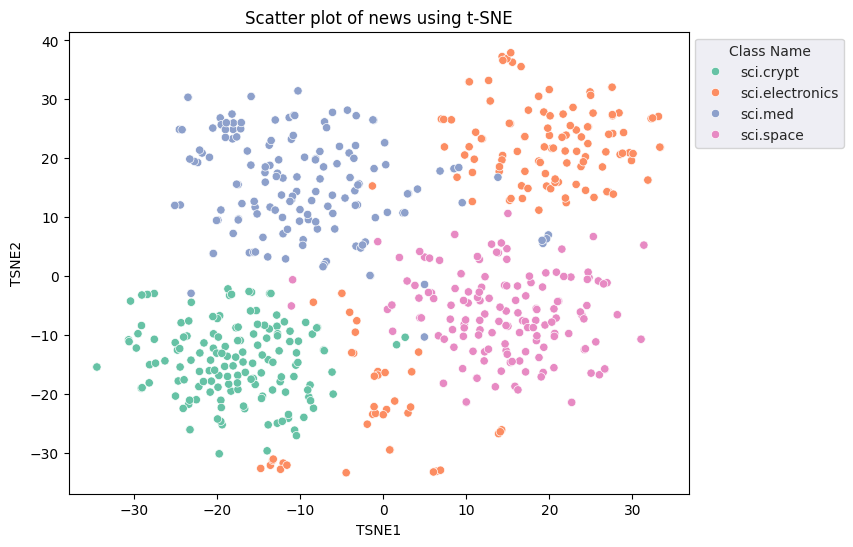

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))  # Set figsize
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
sns.scatterplot(data=df_tsne, x="TSNE1", y="TSNE2", hue="Class Name", palette="Set2")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Scatter plot of news using t-SNE")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2");

## Outlier detection

To determine which points are anomalous, you will determine which points are inliers and outliers. Start by finding the centroid, or location that represents the center of the cluster, and use the distance to determine the points that are outliers.

Start by getting the centroid of each category.

In [18]:
def get_centroids(df_tsne):
    # Get the centroid of each cluster
    centroids = df_tsne.groupby("Class Name").mean()
    return centroids


centroids = get_centroids(df_tsne)
centroids

,TSNE1,TSNE2
Class Name,,
sci.crypt,-17.842558,-14.622563
sci.electronics,14.254175,10.551423
sci.med,-9.633056,15.598600
sci.space,14.849483,-6.457492


In [19]:
def get_embedding_centroids(df):
    emb_centroids = dict()
    grouped = df.groupby("Class Name")
    for c in grouped.groups:
        sub_df = grouped.get_group(c)
        # Get the centroid value of dimension 768
        emb_centroids[c] = np.mean(sub_df["Embeddings"], axis=0)

    return emb_centroids

In [20]:
emb_c = get_embedding_centroids(df_train)

Plot each centroid you have found against the rest of the points.

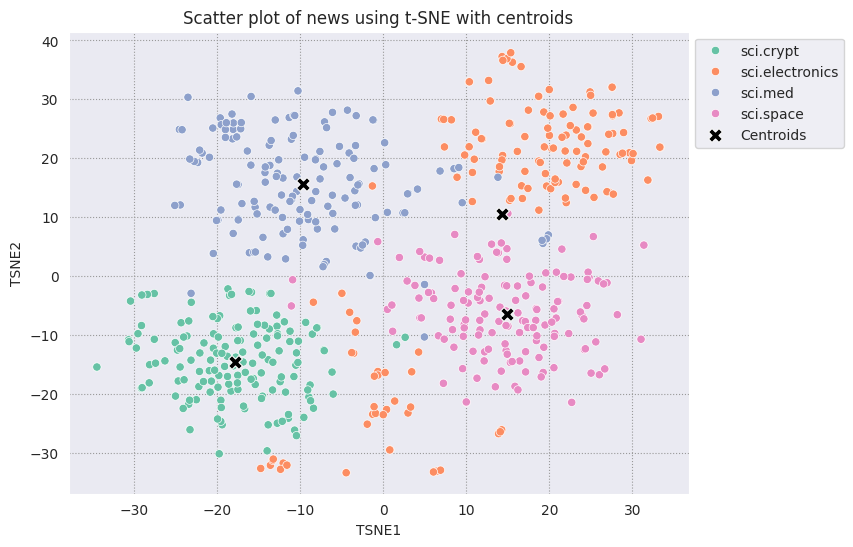

In [21]:
# Plot the centroids against the cluster
fig, ax = plt.subplots(figsize=(8, 6))  # Set figsize
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
sns.scatterplot(data=df_tsne, x="TSNE1", y="TSNE2", hue="Class Name", palette="Set2")
sns.scatterplot(
    data=centroids,
    x="TSNE1",
    y="TSNE2",
    color="black",
    marker="X",
    s=100,
    label="Centroids",
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Scatter plot of news using t-SNE with centroids")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2");

Choose a radius. Anything beyond this bound from the centroid of that category is considered an outlier.

In [22]:
def calculate_euclidean_distance(p1, p2):
    return np.sqrt(np.sum(np.square(p1 - p2)))


def detect_outlier(df, emb_centroids, radius):
    for idx, row in df.iterrows():
        class_name = row["Class Name"]  # Get class name of row
        # Compare centroid distances
        dist = calculate_euclidean_distance(
            row["Embeddings"], emb_centroids[class_name]
        )
        df.at[idx, "Outlier"] = dist > radius

    return len(df[df["Outlier"] == True])

In [23]:
range_ = np.arange(0.3, 0.75, 0.02).round(decimals=2).tolist()
num_outliers = []
for i in range_:
    num_outliers.append(detect_outlier(df_train, emb_c, i))

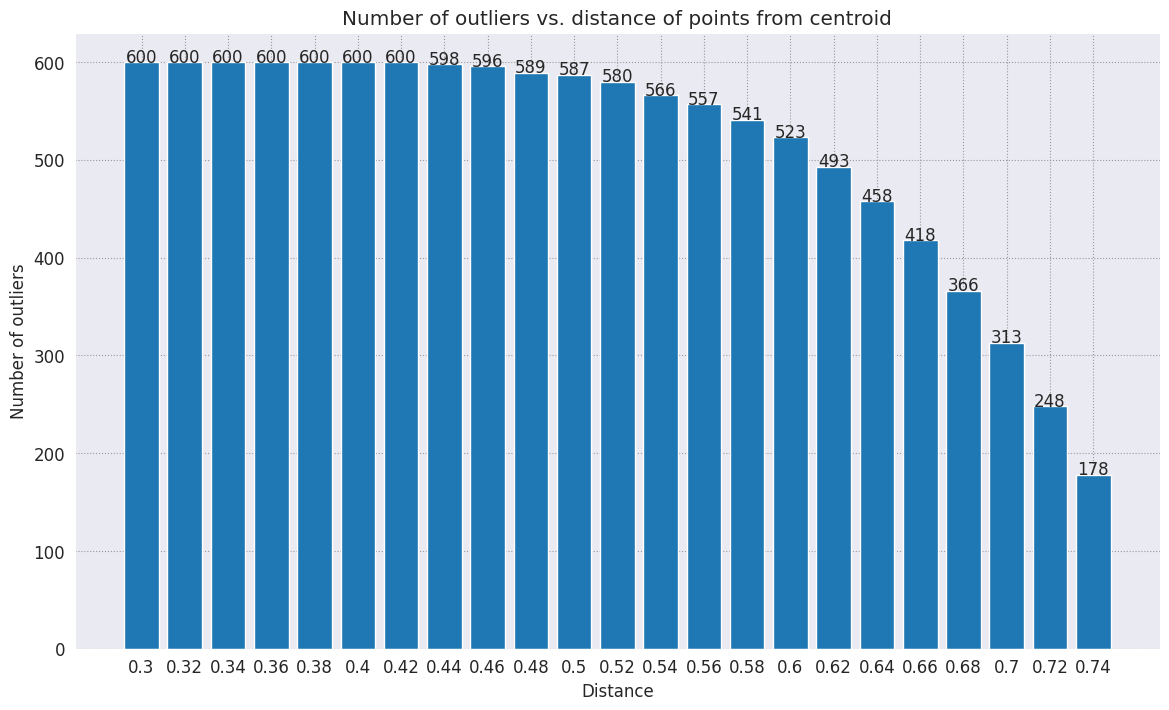

In [24]:
# Plot range_ and num_outliers
fig = plt.figure(figsize=(14, 8))
plt.rcParams.update({"font.size": 12})
plt.bar(list(map(str, range_)), num_outliers)
plt.title("Number of outliers vs. distance of points from centroid")
plt.xlabel("Distance")
plt.ylabel("Number of outliers")
for i in range(len(range_)):
    plt.text(i, num_outliers[i], num_outliers[i], ha="center")

plt.show()

Depending on how sensitive you want your anomaly detector to be, you can choose which radius you would like to use. For now, 0.62 is used, but you can change this value.

In [25]:
# View the points that are outliers
RADIUS = 0.62
detect_outlier(df_train, emb_c, RADIUS)
df_outliers = df_train[df_train["Outlier"] == True]
df_outliers.head()

,Text,Label,Class Name,Embeddings,Outlier
1,Who should be hearing my views on Clipper ?\n...,11,sci.crypt,"[0.030552756, 0.039071944, -0.06493692, 0.0282...",True
3,"Re: powerful ""similarity"" too\nOrganization: ...",11,sci.crypt,"[-0.031461038, 0.019230414, -0.055318035, 0.04...",True
4,Re: text of White House announcement and Q&As...,11,sci.crypt,"[0.046011396, 0.041186202, -0.046594415, 0.010...",True
5,Re: PGP ideas for IBM systems\nLines: 7\n\n: ...,11,sci.crypt,"[0.03722855, -0.011499766, -0.047393054, -0.01...",True
6,Re: Clipper considered harmful\nDistribution:...,11,sci.crypt,"[0.009674275, 0.0353502, -0.046515312, 0.00995...",True


In [26]:
# Use the index to map the outlier points back to the projected TSNE points
outliers_projected = df_tsne.loc[df_outliers["Outlier"].index]

Plot the outliers and denote them using a transparent red color.

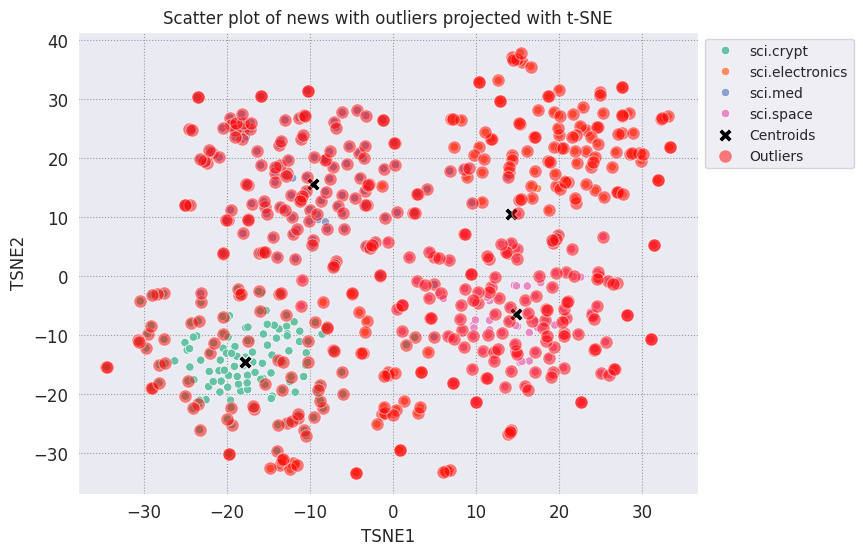

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))  # Set figsize
plt.rcParams.update({"font.size": 10})
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
sns.scatterplot(data=df_tsne, x="TSNE1", y="TSNE2", hue="Class Name", palette="Set2")
sns.scatterplot(
    data=centroids,
    x="TSNE1",
    y="TSNE2",
    color="black",
    marker="X",
    s=100,
    label="Centroids",
)
# Draw a red circle around the outliers
sns.scatterplot(
    data=outliers_projected,
    x="TSNE1",
    y="TSNE2",
    color="red",
    marker="o",
    alpha=0.5,
    s=90,
    label="Outliers",
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Scatter plot of news with outliers projected with t-SNE")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2");

Use the index values of the datafames to print a few examples of what outliers can look like in each category. Here, the first data point from each category is printed out. Explore other points in each category to see data that are deemed as outliers, or anomalies.

In [28]:
sci_crypt_outliers = df_outliers[df_outliers["Class Name"] == "sci.crypt"]
print(sci_crypt_outliers["Text"].iloc[0])

 Who should be hearing my views on Clipper ?
Organization: San Francisco State University
Distribution: na
Lines: 18


Being a browser of this group for some time,
  and being very concerned about the clipper chip proposal,
    I am hoping someone with more knowledge can help out.

Who would be the most influential people to write to, protesting 
the obvious next step hinted at by this proposal ?
 

What are the major flaws in the plan ?
 


-- 
  Shaun P. Hughes                          "Facts are Stupid Things."
                  Ronald Reagan
                                            Republican National
  Finger for PGP 2.2 Public Key             Convention 1988



In [29]:
sci_elec_outliers = df_outliers[df_outliers["Class Name"] == "sci.electronics"]
print(sci_elec_outliers["Text"].iloc[0])

 Re: Help with ultra-long timing
Organization: Lehigh University
Lines: 49


In article <>, 
du writes:
>I have a project that was drooped in my lap that is somewhat a pain to design.
>What I am looking for is a stable ultra-long solid state timer. What they want
>to do is to place this thing on the Antartic ice shelf and measure the amount
>of snow fall over a period of six weeks. Every two weeks, they want to trip a
>selonoid to discharge different colored pellets by gas pressure out across the
>snow. Then by digging down into the snow, the snow fall amount can be measured
>as they come to the different color pellets.
>
>The problem is trying to build a timer that would stand the cold 
>and a power source that wouldn't drain. I have looked at the XR-2204 timers and
>the standard NE556 dual timers, but thier temp specs won't go that low. Also,
>two weeks equates to 1,209,600 seconds per firing, which means one big timing
>cap ! I have found 2.2 farad  caps that have a working voltage 

In [30]:
sci_med_outliers = df_outliers[df_outliers["Class Name"] == "sci.med"]
print(sci_med_outliers["Text"].iloc[0])

 Recurrent Respiratory Papillomatosis
Originator: 
Nntp-Posting-Host: lindsay.princeton.edu
Organization: Princeton University
Distribution: nj
Lines: 43


We will be holding a bake and craft sale at Communiversity in Princeton on  
Nassau Street, Saturday April 24th 12-4 p.m. to benefit the Recurrent  
Respiratory Papillomatosis Foundation, a nonprofit foundation established to  
encourage research toward a cure for Recurrent Respiratory Papillomatosis.  Our  
three year old daughter suffers from this disease.  Below is a press release  
that appeared in local newspapers.  Hope you can join us.


On Saturday, April 24 as part of Communiversity in Princeton, a local family  
will be having a bake and craft sale to raise money for and create public  
awareness about a rare disease called Recurrent Respiratory Papillomatosis.

Bill and Marlene Stern's daughter Lindsay is afflicted with this disease  
characterized by tumors attacking the inside of the larynx, vocal cords and  
trachea.  

In [31]:
sci_space_outliers = df_outliers[df_outliers["Class Name"] == "sci.space"]
print(sci_space_outliers["Text"].iloc[0])

 Re: Did any DC-X gifs show up?
Organization: University of Illinois at Urbana
Lines: 30

  writes:

>In article <1qgiah$>   writes:
>>The rollout was great and I got lots of great shots. I attended
>>the press briefing and got shots of the DC-Y model, too. All
>>in 3D
>>
>>David H. Mitchell
>>
>>
>David,
>	Are you still planing on scanning these and posting them
>somewhere?  Hope Hope Hope.  If you could that would be GREAT.

>Thanks for report of the rollout as well
>take care
>Doug

	They did the rollout already??!?  I am going to have to pay more
attention to the news.  Are any of the gifs headed for wuarchive??
 

Patrick


-- 
Patrick Grady 		      |How do they manage it, these humans-beginning
     |each time so innocently, yet always ending up
  |with the most blood on their hands?
			      |Fathertree to bugger, O.S. Card's _Xenocide_



## Next steps

You've now created an anomaly detector using embeddings! Try using your own textual data to visualize them as embeddings, and choose some bound such that you can detect outliers. You can perform dimensionality reduction in order to complete the visualization step. Note that t-SNE is good at clustering inputs, but can take a longer time to converge or might get stuck at local minima. If you run into this issue, another technique you could consider are [principal components analysis (PCA)](https://en.wikipedia.org/wiki/Principal_component_analysis).

## Outlier with PCA

In [32]:
from sklearn.decomposition import PCA
import plotly.express as px


In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [35]:
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1])
fig.update_layout(
    title="PCA visualization of Custom Classification dataset",
    xaxis_title="First Principal Component",
    yaxis_title="Second Principal Component",
)
fig.show()

In [36]:
df_pca = pd.DataFrame(X_pca, columns=["pca1", "pca2"])
df_pca["Class Name"] = df_train[
    "Class Name"
]  # Add labels column from df_train to df_tsne
df_pca

,pca1,pca2,Class Name
0,-0.374003,0.003083,sci.crypt
1,-0.274922,-0.008286,sci.crypt
2,-0.349355,-0.093054,sci.crypt
3,-0.077383,-0.017818,sci.crypt
4,-0.332086,-0.090462,sci.crypt
...,...,...,...
595,0.099659,-0.032812,sci.space
596,0.120204,-0.192347,sci.space
597,0.121197,-0.142848,sci.space
598,0.038728,-0.233892,sci.space


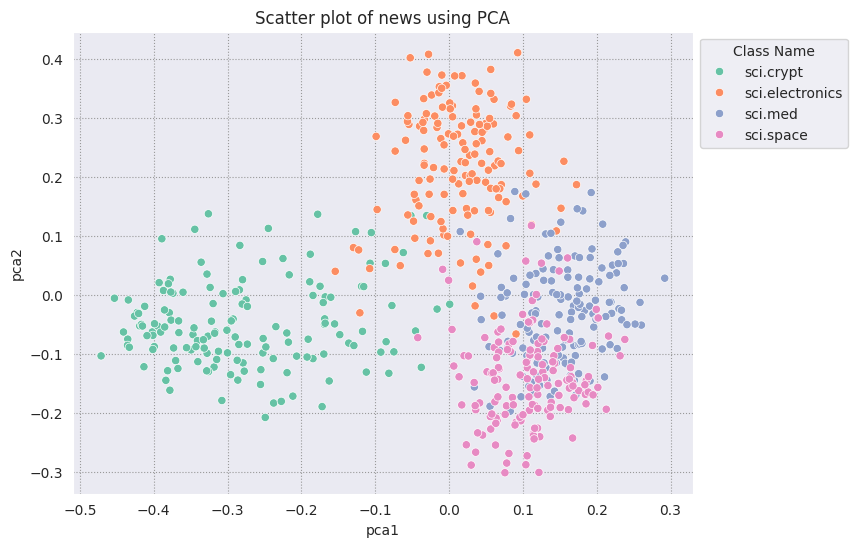

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))  # Set figsize
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
sns.scatterplot(data=df_pca, x="pca1", y="pca2", hue="Class Name", palette="Set2")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Scatter plot of news using PCA")
plt.xlabel("pca1")
plt.ylabel("pca2");

In [38]:
def get_pca_centroids(df_pca):
    # Get the centroid of each cluster
    centroids = df_pca.groupby("Class Name").mean()
    return centroids


In [39]:
centroids = get_pca_centroids(df_pca)
centroids

,pca1,pca2
Class Name,,
sci.crypt,-0.275984,-0.049740
sci.electronics,0.014861,0.218448
sci.med,0.152995,-0.028473
sci.space,0.108127,-0.140235


In [40]:
emb_c = get_embedding_centroids(df_train)

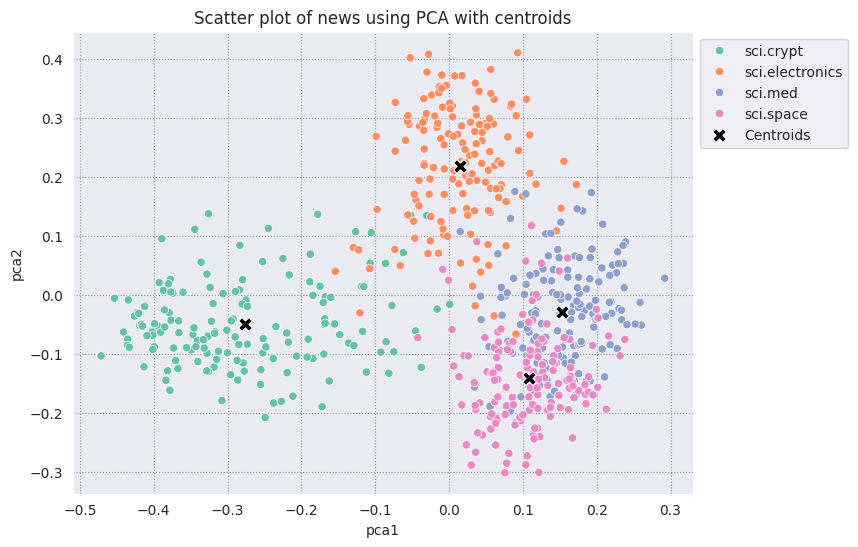

In [41]:
# Plot the centroids against the cluster
fig, ax = plt.subplots(figsize=(8, 6))  # Set figsize
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
sns.scatterplot(data=df_pca, x="pca1", y="pca2", hue="Class Name", palette="Set2")
sns.scatterplot(
    data=centroids,
    x="pca1",
    y="pca2",
    color="black",
    marker="X",
    s=100,
    label="Centroids",
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Scatter plot of news using PCA with centroids")
plt.xlabel("pca1")
plt.ylabel("pca2");

In [42]:
def detect_pca_outlier(df, emb_centroids, radius):
    for idx, row in df.iterrows():
        class_name = row["Class Name"]  # Get class name of row
        # Compare centroid distances
        dist = calculate_euclidean_distance(
            row["Embeddings"], emb_centroids[class_name]
        )
        df.at[idx, "Outlier"] = dist > radius

    return len(df[df["Outlier"] == True])

In [43]:
range_ = np.arange(0.3, 0.75, 0.02).round(decimals=2).tolist()
num_outliers = []
for i in range_:
    num_outliers.append(detect_pca_outlier(df_train, emb_c, i))

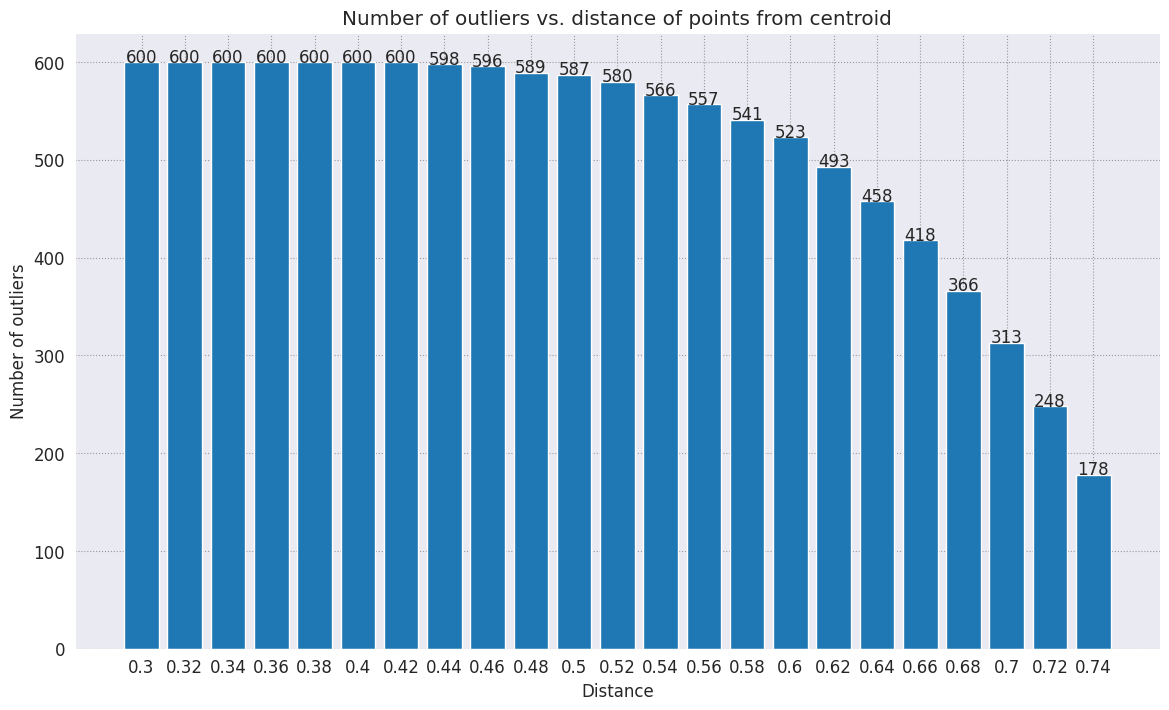

In [44]:
# Plot range_ and num_outliers
fig = plt.figure(figsize=(14, 8))
plt.rcParams.update({"font.size": 12})
plt.bar(list(map(str, range_)), num_outliers)
plt.title("Number of outliers vs. distance of points from centroid")
plt.xlabel("Distance")
plt.ylabel("Number of outliers")
for i in range(len(range_)):
    plt.text(i, num_outliers[i], num_outliers[i], ha="center")

plt.show()

In [45]:
# View the points that are outliers
RADIUS = 0.62
detect_outlier(df_train, emb_c, RADIUS)
df_outliers = df_train[df_train["Outlier"] == True]
df_outliers.head()

,Text,Label,Class Name,Embeddings,Outlier
1,Who should be hearing my views on Clipper ?\n...,11,sci.crypt,"[0.030552756, 0.039071944, -0.06493692, 0.0282...",True
3,"Re: powerful ""similarity"" too\nOrganization: ...",11,sci.crypt,"[-0.031461038, 0.019230414, -0.055318035, 0.04...",True
4,Re: text of White House announcement and Q&As...,11,sci.crypt,"[0.046011396, 0.041186202, -0.046594415, 0.010...",True
5,Re: PGP ideas for IBM systems\nLines: 7\n\n: ...,11,sci.crypt,"[0.03722855, -0.011499766, -0.047393054, -0.01...",True
6,Re: Clipper considered harmful\nDistribution:...,11,sci.crypt,"[0.009674275, 0.0353502, -0.046515312, 0.00995...",True


In [46]:
# Use the index to map the outlier points back to the projected TSNE points
outliers_projected = df_pca.loc[df_outliers["Outlier"].index]

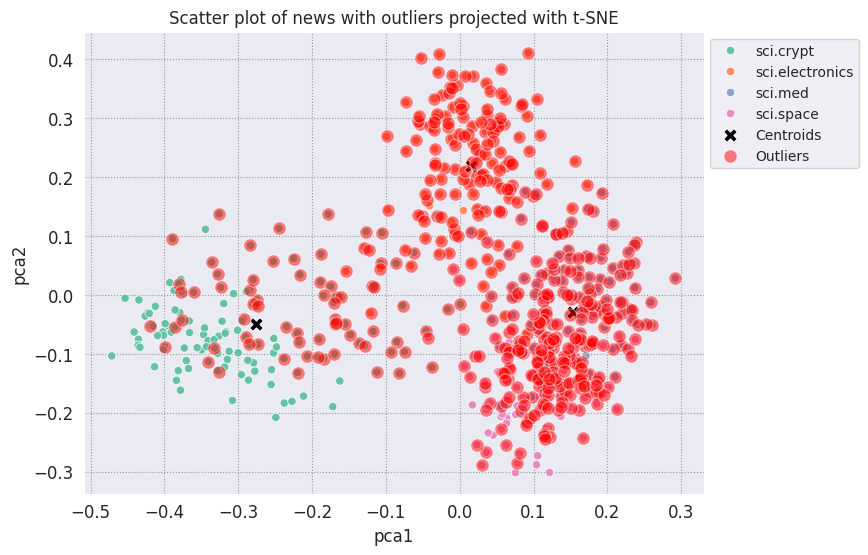

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))  # Set figsize
plt.rcParams.update({"font.size": 10})
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
sns.scatterplot(data=df_pca, x="pca1", y="pca2", hue="Class Name", palette="Set2")
sns.scatterplot(
    data=centroids,
    x="pca1",
    y="pca2",
    color="black",
    marker="X",
    s=100,
    label="Centroids",
)
# Draw a red circle around the outliers
sns.scatterplot(
    data=outliers_projected,
    x="pca1",
    y="pca2",
    color="red",
    marker="o",
    alpha=0.5,
    s=90,
    label="Outliers",
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Scatter plot of news with outliers projected with t-SNE")
plt.xlabel("pca1")
plt.ylabel("pca2");

In [48]:
sci_crypt_outliers = df_outliers[df_outliers["Class Name"] == "sci.crypt"]
print(sci_crypt_outliers["Text"].iloc[0])

 Who should be hearing my views on Clipper ?
Organization: San Francisco State University
Distribution: na
Lines: 18


Being a browser of this group for some time,
  and being very concerned about the clipper chip proposal,
    I am hoping someone with more knowledge can help out.

Who would be the most influential people to write to, protesting 
the obvious next step hinted at by this proposal ?
 

What are the major flaws in the plan ?
 


-- 
  Shaun P. Hughes                          "Facts are Stupid Things."
                  Ronald Reagan
                                            Republican National
  Finger for PGP 2.2 Public Key             Convention 1988

